In [145]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


In [146]:

movies = pd.read_csv("C:/Users/KIIT0001/Desktop/AI-Retention-System/data/movies.csv")

ratings = pd.read_csv("C:/Users/KIIT0001/Desktop/AI-Retention-System/data/ratings.csv")

print(movies.shape)
print(ratings.shape)


(87585, 3)
(32000204, 4)


In [147]:
ratings.head()
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [148]:
# keep larger sample (better quality)
ratings = ratings.sample(420000, random_state=42)

print("After sampling:", ratings.shape)


After sampling: (420000, 4)


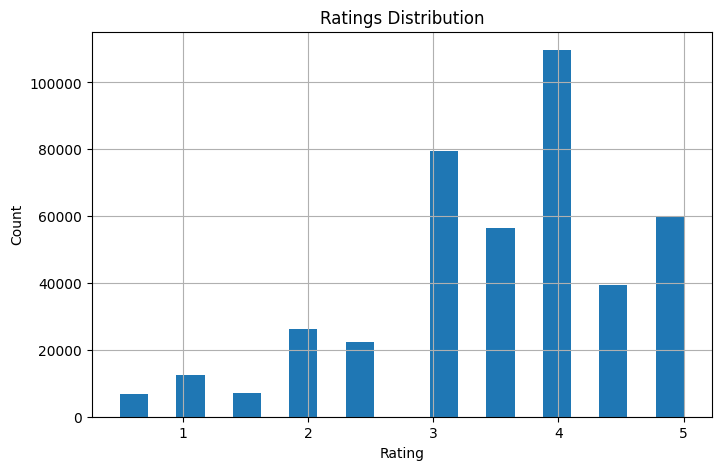

In [149]:
plt.figure(figsize=(8,5))
ratings['rating'].hist(bins=20)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


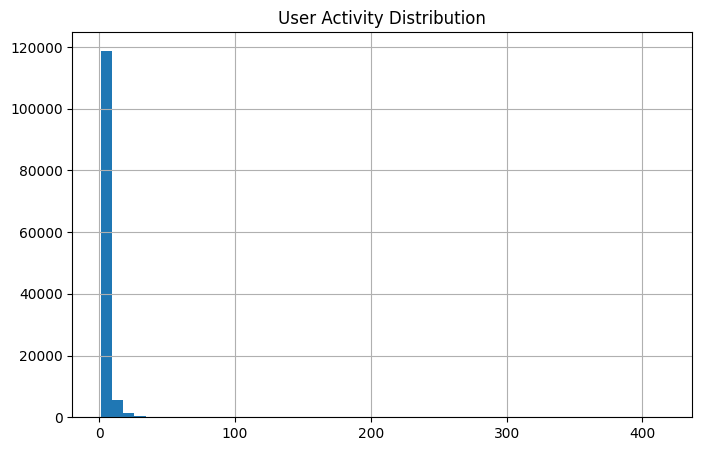

In [150]:
user_counts = ratings['userId'].value_counts()

plt.figure(figsize=(8,5))
user_counts.hist(bins=50)
plt.title("User Activity Distribution")
plt.show()


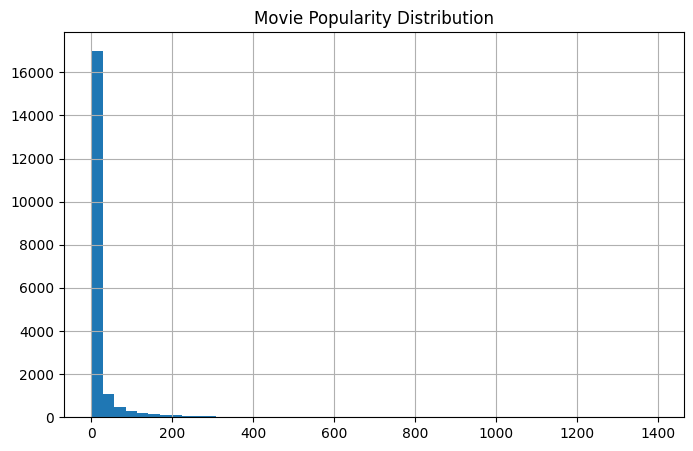

In [151]:
movie_counts = ratings['movieId'].value_counts()

plt.figure(figsize=(8,5))
movie_counts.hist(bins=50)
plt.title("Movie Popularity Distribution")
plt.show()


In [152]:
# keep only very low-noise removal
popular_movies = movie_counts[movie_counts > 10].index
ratings = ratings[ratings['movieId'].isin(popular_movies)]

active_users = user_counts[user_counts > 5].index
ratings = ratings[ratings['userId'].isin(active_users)]

print("After filtering:", ratings.shape)


After filtering: (175051, 4)


In [153]:
movie_user_matrix = ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating'
).fillna(0)

print("Matrix shape:", movie_user_matrix.shape)


Matrix shape: (4939, 18602)


In [154]:
movie_user_matrix = movie_user_matrix.astype('float32')


In [155]:
movie_similarity = cosine_similarity(movie_user_matrix)

print("Similarity computed")


Similarity computed


In [156]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

# reduce precision (VERY IMPORTANT 🔥)
movie_similarity_df = movie_similarity_df.round(3)


In [157]:
def recommend_movies(movie_id, top_n=10):
    sim_scores = movie_similarity_df.loc[movie_id].sort_values(ascending=False)
    sim_scores = sim_scores.iloc[1:top_n+1]
    
    return movies[movies['movieId'].isin(sim_scores.index)]['title'].tolist()


sample = movie_user_matrix.index[0]
recommend_movies(sample)


['Jeffrey (1995)',
 'Major Payne (1995)',
 'Gay Divorcee, The (1934)',
 'Victor/Victoria (1982)',
 'Friday the 13th Part V: A New Beginning (1985)',
 'Apple Dumpling Gang Rides Again, The (1979)',
 'Me Myself I (2000)',
 'Public Enemy, The (1931)',
 'Cinderella Story, A (2004)',
 'Atomic Blonde (2017)']

In [158]:
# joblib.dump(movie_similarity_df, "movie_similarity.pkl")
# joblib.dump(movies, "movies.pkl")

# print("Saved successfully")


In [159]:
# merge datasets
df = ratings.merge(movies, on="movieId")

# pivot (movie-user)
movie_user_matrix = df.pivot_table(
    index="movieId",
    columns="userId",
    values="rating"
).fillna(0)

# reduce size (VERY IMPORTANT 🔥)
movie_user_matrix = movie_user_matrix.iloc[:5000, :3000]

# similarity
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(movie_user_matrix)

# convert to dataframe
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

# save
import joblib
joblib.dump(movie_similarity_df, "movie_similarity.pkl")
joblib.dump(movies, "movies.pkl")


['movies.pkl']